# 50.007 Machine Learning — Course Project
## GenAI Content Detection: human-authored vs machine-generated text

**Team: TheHomiesML**

This notebook contains our code for Tasks 1 to 3.

| Section | Task | Models |
|---|---|---|
| 0 | Setup and dataset understanding | — |
| 1 | Logistic Regression **from scratch** | Logistic Regression |
| 2 | PCA + KNN (`n_neighbors=2`) | KNN on 2000 / 1000 / 500 / 100 components |
| 3 | Other models, race to the top | Naive Bayes, Complement NB, linear classifier by SGD, Extra Trees, soft vote, hybrid TF-IDF + stylometry |

**On the "from scratch" rule.** Task 1 and Task 3 models are written out in
this notebook using NumPy only — no sklearn estimator learns the task, and the
Macro F1 metric in `src/evaluation.py` is written out from its definition
rather than imported. sklearn appears in exactly three places: PCA and KNN in
Task 2 (the brief allows it), Extra Trees in Task 3 (the brief allows
libraries for ensemble models), and KMeans in Section 3.7 — used only to group
training rows into topic clusters for a harder validation split, never to
predict a label.

Every experiment uses one fixed train/validation split, shared across the
team, and `random_state=42` throughout.

---
## 0. Setup and dataset understanding

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Works whether the notebook is opened from the repository root or notebooks/.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.evaluation import calculate_macro_f1
from src.submission import create_submission

DATA_DIR = PROJECT_ROOT / "data"
SUBMISSIONS_DIR = PROJECT_ROOT / "submissions"      # the graded prediction files
# Working output: tuning tables and plots, not deliverables in their own right.
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
for directory in (RESULTS_DIR, SUBMISSIONS_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ID_COLUMN = "id"
LABEL_COLUMN = "label"

print("data files present:",
      all((DATA_DIR / name).exists() for name in
          ["train.csv", "test.csv", "train_features.csv", "test_features.csv"]))

data files present: True


### 0.1 The raw data

`train.csv` and `test.csv` hold the original text. `train_features.csv` and
`test_features.csv` hold the 5000 TF-IDF features the course pre-computed for
us, which Tasks 1 and 2 are required to use.

In [2]:
train_raw = pd.read_csv(DATA_DIR / "train.csv")
test_raw = pd.read_csv(DATA_DIR / "test.csv")

print("train:", train_raw.shape, " test:", test_raw.shape)
print("missing values:", train_raw.isnull().sum().sum(), test_raw.isnull().sum().sum())
train_raw.head(3)

train: (20000, 3)  test: (6999, 2)
missing values: 0 0


,id,text,label
0,71ec6000-1f20-4850-a8f7-140bc6ad640d,Instance-level video segmentation requires a s...,1
1,9a494ddf-43c6-4c54-8927-f2343054fef2,Samples of high-redshift galaxies are easy to ...,0
2,bc1dc7e4-d773-4c52-bcc1-ed08ba822f92,"Ashley Sibery, 39, persuaded Sital Sibery to t...",1


### 0.2 Class distribution

The classes are not balanced: roughly 62.5% of the training rows are
machine-generated. Because the competition scores **Macro F1**, both classes
count equally regardless of how many rows they have, so this imbalance is
something the models have to be told about rather than something we can ignore.

In [3]:
class_distribution = train_raw[LABEL_COLUMN].value_counts().sort_index()
display(pd.DataFrame({
    "Label": ["0 (human-authored)", "1 (machine-generated)"],
    "Count": class_distribution.values,
    "Percentage": (class_distribution.values / len(train_raw) * 100).round(2),
}))

# A model that always guesses the majority class sets the bar to clear
majority = np.ones(len(train_raw), dtype=int)
print("always-predict-1 Macro F1:",
      round(calculate_macro_f1(train_raw[LABEL_COLUMN], majority), 4))

,Label,Count,Percentage
0,0 (human-authored),7496,37.48
1,1 (machine-generated),12504,62.52


always-predict-1 Macro F1: 0.3847


### 0.3 Text length by class

A quick look at what separates the two classes before any modelling.

In [4]:
import re

lengths = train_raw.assign(
    n_words=train_raw["text"].str.split().str.len(),
    n_chars=train_raw["text"].str.len(),
)
display(lengths.groupby(LABEL_COLUMN)[["n_words", "n_chars"]]
        .agg(["mean", "median", "std"]).round(1))


def sentence_length_std(text):
    """How much sentence length varies inside one document."""
    counts = [len(re.findall(r"\b\w+\b", part))
              for part in re.split(r"[.!?]+", text) if part.strip()]
    return np.std(counts) if len(counts) > 1 else 0.0


sample = train_raw.groupby(LABEL_COLUMN, group_keys=False).sample(2000, random_state=RANDOM_SEED)
display(sample.assign(sentence_std=sample["text"].map(sentence_length_std))
        .groupby(LABEL_COLUMN)["sentence_std"].agg(["mean", "median"]).round(2))

n_words               n_chars                
         mean median    std    mean  median     std
label                                              
0       261.5  176.0  307.2  1529.4  1065.0  1837.8
1       237.6  195.0  186.7  1445.1  1198.0  1120.6

,mean,median
label,,
0,8.86,7.91
1,7.82,6.61


The averages are not the story. Human text has a **higher mean** but a **lower
median** length, with a standard deviation about 1.6x larger — human writing is
right-skewed, mostly short with a long tail, while machine text clusters tightly
around its middle. The same holds inside documents: sentence length varies more
in human writing (8.86 vs 7.82).

The signal is in the **variability**, not the level — and a bag-of-words model
cannot see variability at all. That is the hint we follow up in Section 3.6.

### 0.4 The shared validation split

Every member scored their models against the same 80/20 stratified split, so
the numbers in this notebook are directly comparable with each other. The split
is stored in `data/splits/shared_validation_split.csv`.

In [5]:
split = pd.read_csv(DATA_DIR / "splits" / "shared_validation_split.csv")
assert len(split) == len(train_raw)
assert split[ID_COLUMN].astype("string").tolist() == train_raw[ID_COLUMN].astype("string").tolist()

is_train = (split["split"] == "train").to_numpy()
print("train rows:", is_train.sum(), " validation rows:", (~is_train).sum())
print("class-1 rate — train:", round(train_raw.loc[is_train, LABEL_COLUMN].mean(), 4),
      " validation:", round(train_raw.loc[~is_train, LABEL_COLUMN].mean(), 4))

train rows: 16000  validation rows: 4000
class-1 rate — train: 0.6252  validation: 0.6252


### 0.5 Loading the provided TF-IDF features

Tasks 1 and 2 must use these. Task 3 starts here too, so that the model
comparison is about the models rather than about the features; we only build
our own features later in Section 3.6.

In [6]:
FEATURES = [c for c in pd.read_csv(DATA_DIR / "train_features.csv", nrows=0).columns
            if c not in (ID_COLUMN, LABEL_COLUMN)]
assert len(FEATURES) == 5000, f"expected 5000 features, got {len(FEATURES)}"

dtypes = {c: np.float32 for c in FEATURES}
train_features = pd.read_csv(DATA_DIR / "train_features.csv", dtype=dtypes)
test_features = pd.read_csv(DATA_DIR / "test_features.csv", dtype=dtypes)

X_all = train_features[FEATURES].to_numpy(np.float32)
y_all = train_features[LABEL_COLUMN].to_numpy()
X_test = test_features[FEATURES].to_numpy(np.float32)
test_ids = test_features[ID_COLUMN].copy()

X_train, y_train = X_all[is_train], y_all[is_train]
X_val, y_val = X_all[~is_train], y_all[~is_train]

del train_features
print(X_train.shape, X_val.shape, X_test.shape)

(16000, 5000) (4000, 5000) (6999, 5000)


---
# Task 1 — Logistic Regression from scratch

No logistic regression package is used here. The five functions the brief asks
for are `sigmoid`, `loss`, `gradients`, `train` and `predict`, all written with
NumPy.

**How it works.** Logistic regression puts a linear score
$z = \mathbf{w}^\top \mathbf{x} + b$ through the sigmoid
$\sigma(z) = 1/(1+e^{-z})$ to get a probability. Training minimises the log
loss

$$L = -\frac{1}{m}\sum_{i=1}^{m}\Big[y_i\log\hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\Big]$$

whose gradients take the neat form
$\partial L/\partial \mathbf{w} = \frac{1}{m}X^\top(\hat{\mathbf{y}}-\mathbf{y})$
and $\partial L/\partial b = \frac{1}{m}\sum_i (\hat{y}_i - y_i)$.
We follow those gradients downhill in mini-batches.

### 1.1 Implementation

In [7]:
import numpy as np


def sigmoid(z):
    """Squash any real number into the range (0, 1)."""
    z = np.clip(z, -500, 500)          # prevents exp() overflow
    return 1.0 / (1.0 + np.exp(-z))


def loss(y, y_hat, sample_weight=None):
    """Log loss (binary cross-entropy) between true and predicted labels."""
    eps = 1e-15
    y_hat = np.clip(y_hat, eps, 1 - eps)   # prevents log(0)
    per_row = -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    if sample_weight is None:
        return np.mean(per_row)
    return np.sum(sample_weight * per_row) / np.sum(sample_weight)


def gradients(X, y, y_hat, sample_weight=None):
    """Partial derivatives of the log loss w.r.t. the weights and the bias."""
    m = X.shape[0]
    error = y_hat - y
    if sample_weight is not None:
        error = error * sample_weight
    return (X.T @ error) / m, np.sum(error) / m


def train(X, y, bs, epochs, lr, l2=0.0, class_weight=None, shuffle=True,
          seed=42, verbose=False):
    """Mini-batch gradient descent for logistic regression.

    bs, epochs and lr keep the positional order required by the task brief.
    The keyword arguments are the additions we tuned:

        l2           weight of the L2 penalty (0.0 reproduces the first version)
        class_weight "balanced" to reweight the classes to equal total mass
        shuffle      reshuffle the row order before every epoch
    """
    # A pandas Series would index by label rather than position below, so the
    # batch lookups have to be done on a plain array
    y = np.asarray(y, dtype=np.float64)
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    losses = []
    n_batches = (m - 1) // bs + 1
    rng = np.random.default_rng(seed)

    if class_weight == "balanced":
        classes, counts = np.unique(y, return_counts=True)
        weight_map = {c: m / (len(classes) * count) for c, count in zip(classes, counts)}
        sample_weight = np.array([weight_map[label] for label in y])
    else:
        sample_weight = None

    for epoch in range(epochs):
        # Reshuffling each epoch stops the model from seeing the same fixed
        # batches in the same order every time
        order = rng.permutation(m) if shuffle else np.arange(m)

        for i in range(n_batches):
            batch_idx = order[i * bs:(i + 1) * bs]
            xb = X[batch_idx]
            yb = y[batch_idx]
            swb = None if sample_weight is None else sample_weight[batch_idx]

            y_hat = sigmoid(xb @ w + b)
            dw, db = gradients(xb, yb, y_hat, swb)
            dw = dw + l2 * w                     # L2 penalty, bias left out
            w -= lr * dw
            b -= lr * db

        losses.append(loss(y, sigmoid(X @ w + b), sample_weight))
        if verbose and (epoch + 1) % 50 == 0:
            print(f"  epoch {epoch+1:4d}  loss {losses[-1]:.6f}")

    return w, b, losses


def predict(X, w, b, threshold=0.5):
    """Label each row 1 when its predicted probability clears the threshold."""
    return (sigmoid(X @ w + b) >= threshold).astype(int)


def predict_proba(X, w, b):
    return sigmoid(X @ w + b)

### 1.2 A first fit

Training with the settings we started from, to confirm the loss actually goes
down and the model learns something better than guessing.

  epoch   50  loss 0.448315


  epoch  100  loss 0.403218


  epoch  150  loss 0.377922


  epoch  200  loss 0.360634


  epoch  250  loss 0.347668


  epoch  300  loss 0.337394
loss: 0.6407 -> 0.3374
validation Macro F1: 0.7352


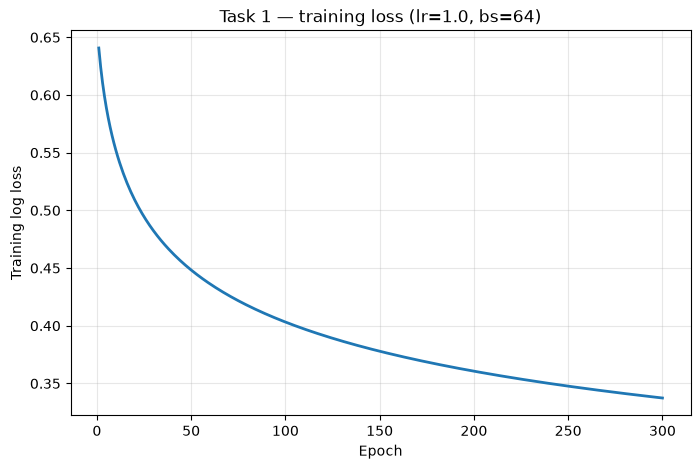

In [8]:
w, b, losses = train(X_train, y_train.astype(np.float64),
                     bs=64, epochs=300, lr=1.0, shuffle=False, verbose=True)

print("loss:", round(losses[0], 4), "->", round(losses[-1], 4))
print("validation Macro F1:", round(calculate_macro_f1(y_val, predict(X_val, w, b)), 4))
assert losses[-1] < losses[0], "loss should decrease"

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(losses) + 1), losses, linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("Training log loss")
plt.title("Task 1 — training loss (lr=1.0, bs=64)")
plt.grid(alpha=0.3)
plt.savefig(FIGURES_DIR / "logreg_training_loss.png", dpi=150)
plt.show()

### 1.3 Tuning

Three things are varied against that starting point:

1. **Shuffling** the rows before each epoch, instead of reusing one fixed
   batch order every time.
2. An **L2 penalty**, since 5000 features on 16000 rows leaves room to overfit.
3. The **decision threshold**. This is the one that matters most: Macro F1 on a
   62.5 / 37.5 split is not maximised at the default 0.5 cut-off, because
   moving the cut-off trades recall on one class for the other and the two
   classes are weighted equally in the metric.

The threshold search is shared with Task 3, so it lives alongside the models:

In [9]:
def best_threshold(y_true, scores, metric, low=0.05, high=0.95, steps=91):
    """Pick the cut-off on `scores` with the best metric value.

    The grid is deliberately coarse: a finer one just fits the noise in a
    single 4000-row validation split.
    """
    candidates = np.quantile(scores, np.linspace(low, high, steps))
    values = [metric(y_true, (scores >= t).astype(int)) for t in candidates]
    best = int(np.argmax(values))
    return float(candidates[best]), float(values[best])

In [10]:
results = []


def run_config(label, **kwargs):
    settings = {"bs": 64, "epochs": 300, "lr": 1.0}
    settings.update(kwargs)

    t0 = time.time()
    w, b, hist = train(X_train, y_train.astype(np.float64), **settings)
    probabilities = predict_proba(X_val, w, b)

    default_f1 = calculate_macro_f1(y_val, (probabilities >= 0.5).astype(int))
    threshold, tuned_f1 = best_threshold(y_val, probabilities, calculate_macro_f1)

    results.append({
        "config": label,
        "learning_rate": settings["lr"], "epochs": settings["epochs"],
        "batch_size": settings["bs"], "l2": settings.get("l2", 0.0),
        "class_weight": str(settings.get("class_weight")),
        "shuffle": settings.get("shuffle", True),
        "final_train_loss": hist[-1],
        "val_macro_f1": default_f1,
        "best_threshold": threshold,
        "val_macro_f1_tuned": tuned_f1,
        "runtime_s": round(time.time() - t0, 1),
    })
    print(f"{label:<40} F1={default_f1:.4f}  tuned={tuned_f1:.4f} (t={threshold:.3f})")


run_config("baseline (no shuffle, no L2)", shuffle=False)
run_config("shuffle")
for l2 in [1e-5, 1e-4, 1e-3]:
    run_config(f"shuffle + l2={l2}", l2=l2)
run_config("shuffle + l2=1e-05 + balanced", l2=1e-5, class_weight="balanced")
for lr in [0.5, 2.0]:
    run_config(f"shuffle + l2=1e-05 + lr={lr}", l2=1e-5, lr=lr)
run_config("shuffle + l2=1e-05 + epochs=500", l2=1e-5, epochs=500)

logreg_results = (pd.DataFrame(results)
                  .sort_values("val_macro_f1_tuned", ascending=False)
                  .reset_index(drop=True))
logreg_results.to_csv(RESULTS_DIR / "logreg_tuning_results.csv", index=False)
logreg_results

baseline (no shuffle, no L2)             F1=0.7352  tuned=0.7376 (t=0.586)


shuffle                                  F1=0.7254  tuned=0.7386 (t=0.631)


shuffle + l2=1e-05                       F1=0.7225  tuned=0.7394 (t=0.587)


shuffle + l2=0.0001                      F1=0.6444  tuned=0.7389 (t=0.614)


shuffle + l2=0.001                       F1=0.4005  tuned=0.6943 (t=0.650)


shuffle + l2=1e-05 + balanced            F1=0.7353  tuned=0.7410 (t=0.476)


shuffle + l2=1e-05 + lr=0.5              F1=0.7227  tuned=0.7440 (t=0.627)


shuffle + l2=1e-05 + lr=2.0              F1=0.7167  tuned=0.7393 (t=0.608)


shuffle + l2=1e-05 + epochs=500          F1=0.7374  tuned=0.7391 (t=0.530)


,config,learning_rate,epochs,batch_size,l2,class_weight,shuffle,final_train_loss,val_macro_f1,best_threshold,val_macro_f1_tuned,runtime_s
0,shuffle + l2=1e-05 + lr=0.5,0.5,300,64,0.00001,None,True,0.394779,0.722655,0.627466,0.743964,19.2
1,shuffle + l2=1e-05 + balanced,1.0,300,64,0.00001,balanced,True,0.379213,0.735279,0.475968,0.741029,19.2
2,shuffle + l2=1e-05,1.0,300,64,0.00001,None,True,0.368193,0.722498,0.586793,0.739416,20.1
3,shuffle + l2=1e-05 + lr=2.0,2.0,300,64,0.00001,None,True,0.354395,0.716698,0.607588,0.739262,19.3
4,shuffle + l2=1e-05 + epochs=500,1.0,500,64,0.00001,None,True,0.356059,0.737351,0.530154,0.739055,31.9
5,shuffle + l2=0.0001,1.0,300,64,0.00010,None,True,0.486014,0.644443,0.613959,0.738878,19.2
6,shuffle,1.0,300,64,0.00000,None,True,0.338709,0.725436,0.631437,0.738641,20.9
7,"baseline (no shuffle, no L2)",1.0,300,64,0.00000,None,False,0.337394,0.735212,0.585621,0.737592,17.6
8,shuffle + l2=0.001,1.0,300,64,0.00100,None,True,0.608250,0.400481,0.650381,0.694334,19.2


**Reading the table.** The gains are real but small. Shuffling on its own does
not reliably help, a light L2 (`1e-5`) helps a little, and the threshold is
worth roughly +0.01. The spread across the top few rows is about 0.005, which
is inside the noise of a 4000-row validation set — so we should not read much
into the exact ordering of the leaders.

In [11]:
best = logreg_results.iloc[0]
BEST_LR = float(best["learning_rate"])
BEST_EPOCHS = int(best["epochs"])
BEST_BS = int(best["batch_size"])
BEST_L2 = float(best["l2"])
BEST_CLASS_WEIGHT = None if best["class_weight"] == "None" else best["class_weight"]
BEST_SHUFFLE = bool(best["shuffle"])
BEST_THRESHOLD = float(best["best_threshold"])

print(f"selected: lr={BEST_LR}, epochs={BEST_EPOCHS}, bs={BEST_BS}, l2={BEST_L2}, "
      f"class_weight={BEST_CLASS_WEIGHT}, threshold={BEST_THRESHOLD:.4f}")
print("validation Macro F1:", round(float(best["val_macro_f1_tuned"]), 4))

selected: lr=0.5, epochs=300, bs=64, l2=1e-05, class_weight=None, threshold=0.6275
validation Macro F1: 0.744


### 1.4 Refit on all labelled data and predict the test set

The hyperparameters are fixed above using the validation split; the final model
is then refitted on all 20000 labelled rows so it sees as much data as possible.

In [12]:
final_w, final_b, _ = train(X_all, y_all.astype(np.float64),
                            bs=BEST_BS, epochs=BEST_EPOCHS, lr=BEST_LR,
                            l2=BEST_L2, class_weight=BEST_CLASS_WEIGHT,
                            shuffle=BEST_SHUFFLE, verbose=True)

logreg_test_preds = predict(X_test, final_w, final_b, threshold=BEST_THRESHOLD)

logreg_submission = create_submission(
    test_ids=test_ids,
    predictions=logreg_test_preds,
    output_path=SUBMISSIONS_DIR / "LogReg_Prediction.csv",
    id_column=ID_COLUMN,
    label_column=LABEL_COLUMN,
)
print("class-1 rate:", round(float(logreg_test_preds.mean()), 4))
logreg_submission.head()

  epoch   50  loss 0.488652


  epoch  100  loss 0.447961


  epoch  150  loss 0.428985


  epoch  200  loss 0.413464


  epoch  250  loss 0.404621


  epoch  300  loss 0.397393
class-1 rate: 0.6755


,id,label
0,59218,1
1,37110,1
2,23200,0
3,e3357348-166e-4847-a06d-158b7cd83aa5,1
4,61615,0


In [13]:
# Format check: right columns, right length, IDs in their original order
saved = pd.read_csv(SUBMISSIONS_DIR / "LogReg_Prediction.csv", dtype={ID_COLUMN: "string"})
assert saved.columns.tolist() == [ID_COLUMN, LABEL_COLUMN]
assert len(saved) == len(test_ids)
assert saved[ID_COLUMN].tolist() == test_ids.astype("string").tolist()
assert saved[LABEL_COLUMN].isnull().sum() == 0
assert set(saved[LABEL_COLUMN].unique()).issubset({0, 1})
print("LogReg_Prediction.csv verified — ready to upload")

LogReg_Prediction.csv verified — ready to upload


---
# Task 2 — PCA and KNN

PCA finds the directions along which the data varies most and re-expresses each
document using only the strongest ones. The brief allows sklearn here, and
fixes `n_neighbors=2`.

In [14]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

N_NEIGHBOURS = 2                       # fixed by the task brief
COMPONENT_SETTINGS = [2000, 1000, 500, 100]


def evaluate_pca(n_components):
    """Fit PCA and KNN on the training split and score on the validation split."""
    start = time.time()

    pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)

    knn = KNeighborsClassifier(n_neighbors=N_NEIGHBOURS)
    knn.fit(X_train_pca, y_train)
    predictions = knn.predict(X_val_pca)

    return {
        "components": n_components,
        "val_macro_f1": calculate_macro_f1(y_val, predictions),
        "explained_variance": float(pca.explained_variance_ratio_.sum()),
        "pred_class1_rate": float(predictions.mean()),
        "runtime_s": round(time.time() - start, 1),
    }


pca_results = pd.DataFrame([evaluate_pca(n) for n in COMPONENT_SETTINGS])
pca_results.to_csv(RESULTS_DIR / "pca_knn_results.csv", index=False)
pca_results

,components,val_macro_f1,explained_variance,pred_class1_rate,runtime_s
0,2000,0.400742,0.781895,0.08300,5.5
1,1000,0.475290,0.567997,0.15125,2.2
2,500,0.560290,0.389543,0.27125,1.1
3,100,0.655640,0.158952,0.44825,0.4


### 2.1 The result is backwards — and that is the interesting part

Macro F1 gets **worse** as we keep more components: 100 components score far
better than 2000, even though 2000 components retain 78% of the variance and
100 retain only 16%. Two things cause this.

**Distance concentration.** KNN depends on some neighbours being meaningfully
closer than others. In high dimensions the distances between a point and all of
its neighbours converge, so "nearest" stops carrying much signal. Cutting to
100 components is what makes the neighbourhoods meaningful again.

**An even `k` needs a tie-break.** With `n_neighbors=2` the two neighbours
often disagree, and sklearn settles a tie by taking the lowest class index —
class 0. The cell below counts how often that happens.

In [15]:
tie_rows = []
for n_components in COMPONENT_SETTINGS:
    pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)

    knn = KNeighborsClassifier(n_neighbors=N_NEIGHBOURS).fit(X_train_pca, y_train)
    _, neighbour_idx = knn.kneighbors(X_val_pca)
    neighbour_labels = y_train[neighbour_idx]

    is_tie = neighbour_labels[:, 0] != neighbour_labels[:, 1]
    tie_rows.append({
        "components": n_components,
        "tie_rate": float(is_tie.mean()),
        "true_class1_rate_among_ties": float(y_val[is_tie].mean()),
        "val_macro_f1_k2": calculate_macro_f1(y_val, knn.predict(X_val_pca)),
        # the nearest neighbour on its own, i.e. the same model without the tie rule
        "val_macro_f1_k1": calculate_macro_f1(y_val, neighbour_labels[:, 0]),
    })

tie_analysis = pd.DataFrame(tie_rows)
tie_analysis.to_csv(RESULTS_DIR / "pca_knn_tie_analysis.csv", index=False)
tie_analysis

,components,tie_rate,true_class1_rate_among_ties,val_macro_f1_k2,val_macro_f1_k1
0,2000,0.23100,0.738095,0.400742,0.494368
1,1000,0.28825,0.666088,0.475290,0.556752
2,500,0.36100,0.603186,0.560290,0.614481
3,100,0.35375,0.547703,0.655640,0.667906


At 2000 components about 23% of validation rows are ties, and roughly 74% of
those tied rows are genuinely class 1 — every one of them is handed to class 0
by the tie-break rule. That is why the model predicts class 1 for only 8% of
rows when the true rate is 63%.

The `k=1` column isolates the effect: dropping the second neighbour, and with
it the tie-break, recovers about 0.09 Macro F1 at 2000 components. We keep
`k=2` because the brief fixes it, but it is the single biggest thing holding
this model back.

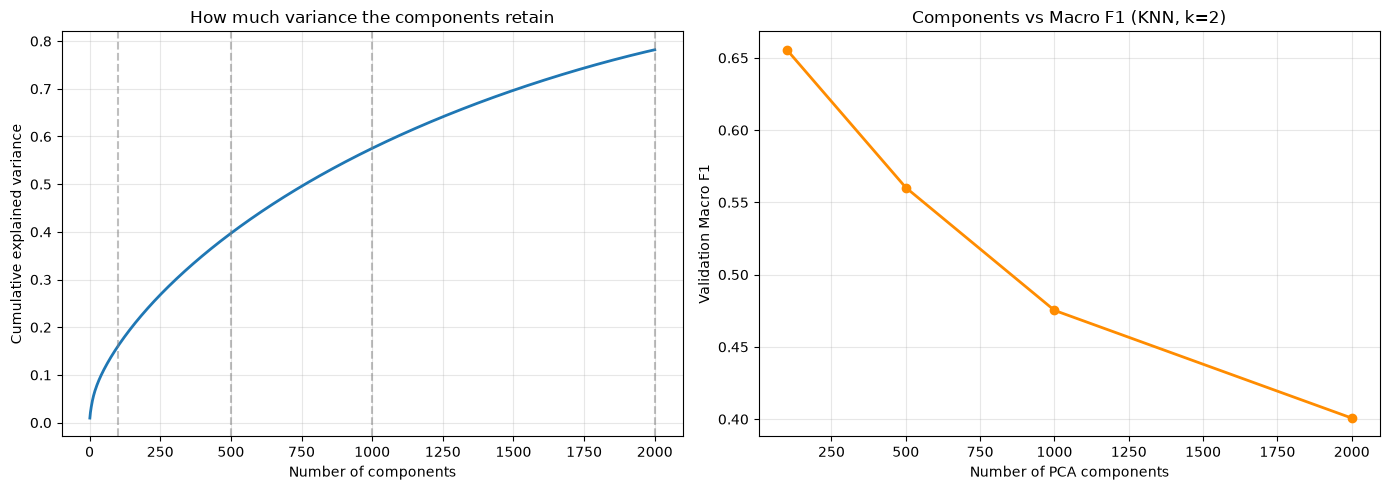

,components,share_of_original_features,cumulative_explained_variance
0,100,0.02,0.160022
1,500,0.10,0.397017
2,1000,0.20,0.575253
3,2000,0.40,0.781896


In [16]:
full_pca = PCA(n_components=max(COMPONENT_SETTINGS), random_state=RANDOM_SEED)
full_pca.fit(X_train)
cumulative_variance = np.cumsum(full_pca.explained_variance_ratio_)

variance_analysis = pd.DataFrame([{
    "components": n,
    "share_of_original_features": n / len(FEATURES),
    "cumulative_explained_variance": float(cumulative_variance[n - 1]),
} for n in sorted(COMPONENT_SETTINGS)])
variance_analysis.to_csv(RESULTS_DIR / "pca_variance_analysis.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linewidth=2)
for n in COMPONENT_SETTINGS:
    axes[0].axvline(n, color="grey", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Number of components"); axes[0].set_ylabel("Cumulative explained variance")
axes[0].set_title("How much variance the components retain"); axes[0].grid(alpha=0.3)

axes[1].plot(pca_results["components"], pca_results["val_macro_f1"],
             marker="o", linewidth=2, color="darkorange")
axes[1].set_xlabel("Number of PCA components"); axes[1].set_ylabel("Validation Macro F1")
axes[1].set_title(f"Components vs Macro F1 (KNN, k={N_NEIGHBOURS})"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_knn_analysis.png", dpi=150)
plt.show()
display(variance_analysis)

### 2.2 The four Kaggle submissions

One file per component setting, each refitted on all 20000 labelled rows.

In [17]:
for n_components in COMPONENT_SETTINGS:
    pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
    X_all_pca = pca.fit_transform(X_all)
    X_test_pca = pca.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=N_NEIGHBOURS).fit(X_all_pca, y_all)
    test_preds = knn.predict(X_test_pca)

    create_submission(
        test_ids=test_ids,
        predictions=test_preds,
        output_path=SUBMISSIONS_DIR / f"PCA{n_components}_KNN_Prediction.csv",
        id_column=ID_COLUMN,
        label_column=LABEL_COLUMN,
    )
    print(f"PCA{n_components}_KNN_Prediction.csv saved; "
          f"class-1 rate={test_preds.mean():.4f}")

PCA2000_KNN_Prediction.csv saved; class-1 rate=0.0590


PCA1000_KNN_Prediction.csv saved; class-1 rate=0.1767


PCA500_KNN_Prediction.csv saved; class-1 rate=0.3686


PCA100_KNN_Prediction.csv saved; class-1 rate=0.5449


---
# Task 3 — Other models

Task 3 requires the models to be written from scratch, and only allows existing
libraries for **ensemble** models. So the Naive Bayes, Complement Naive Bayes
and SGD linear classifier below are all written out with NumPy; Extra Trees is
taken from sklearn because it is an ensemble.

Sections 3.1 to 3.5 all use the provided 5000 TF-IDF features, so the
comparison is about the models. Section 3.6 then changes the features instead —
which turns out to matter far more than the choice of model.

## 3.1 Multinomial Naive Bayes (from scratch)

Naive Bayes applies Bayes' rule and assumes the features are independent given
the class — "naive" because that is plainly false for words, yet it works
anyway. For each class it stores how much total TF-IDF mass each feature
carries, smoothed by `alpha` so an unseen term does not zero out the whole
product, and scores a document by summing log-probabilities.

In [18]:
def nb_fit(X, y, alpha=1.0):
    """Estimate the class priors and the smoothed per-feature likelihoods."""
    classes = np.unique(y)
    class_log_prior = np.zeros(len(classes))
    feature_log_prob = np.zeros((len(classes), X.shape[1]))

    for idx, c in enumerate(classes):
        X_c = X[y == c]
        class_log_prior[idx] = np.log(X_c.shape[0] / X.shape[0])

        # alpha is Laplace/Lidstone smoothing, so unseen terms are not zeroed
        feature_mass = np.asarray(X_c.sum(axis=0)).ravel() + alpha
        feature_log_prob[idx] = np.log(feature_mass / feature_mass.sum())

    return classes, class_log_prior, feature_log_prob


def nb_predict_log_proba(X, class_log_prior, feature_log_prob):
    return X @ feature_log_prob.T + class_log_prior


def nb_predict(X, classes, class_log_prior, feature_log_prob):
    log_proba = nb_predict_log_proba(X, class_log_prior, feature_log_prob)
    return classes[np.argmax(log_proba, axis=1)]


def nb_predict_proba(X, class_log_prior, feature_log_prob):
    log_proba = nb_predict_log_proba(X, class_log_prior, feature_log_prob)
    log_proba -= log_proba.max(axis=1, keepdims=True)   # stabilise before exp
    proba = np.exp(log_proba)
    return proba / proba.sum(axis=1, keepdims=True)

In [19]:
nb_grid = []
for alpha in [0.001, 0.01, 0.1, 0.5, 1.0]:
    classes, prior, feature_log_prob = nb_fit(X_train, y_train, alpha=alpha)
    score = calculate_macro_f1(y_val, nb_predict(X_val, classes, prior, feature_log_prob))
    nb_grid.append({"alpha": alpha, "val_macro_f1": score})
    print(f"alpha={alpha:<7} F1={score:.4f}")

nb_grid = pd.DataFrame(nb_grid).sort_values("val_macro_f1", ascending=False)
nb_grid.to_csv(RESULTS_DIR / "task3_nb_alpha.csv", index=False)
nb_grid

alpha=0.001   F1=0.6741
alpha=0.01    F1=0.6736
alpha=0.1     F1=0.6719
alpha=0.5     F1=0.6680
alpha=1.0     F1=0.6605


,alpha,val_macro_f1
0,0.001,0.674114
1,0.010,0.673634
2,0.100,0.671927
3,0.500,0.667952
4,1.000,0.660464


`alpha` matters a lot here, and smaller is better. The provided features are
TF-IDF weights rather than raw counts, so the per-class mass in each feature is
small; a smoothing constant of 1.0 is then large relative to the real signal
and washes it out.

## 3.2 Complement Naive Bayes (from scratch)

A variant built for uneven class sizes. Rather than asking "how typical is this
document of class *c*", it asks "how *untypical* is it of everything that is
not *c*", and it normalises the weights so long documents cannot dominate.

In [20]:
def cnb_fit(X, y, alpha=1.0, normalize=True):
    classes = np.unique(y)
    complement_weights = np.zeros((len(classes), X.shape[1]))
    total_feature_mass = np.asarray(X.sum(axis=0)).ravel()

    for idx, c in enumerate(classes):
        class_feature_mass = np.asarray(X[y == c].sum(axis=0)).ravel()
        complement_mass = total_feature_mass - class_feature_mass + alpha

        weights = np.log(complement_mass / complement_mass.sum())
        if normalize:
            # keeps long documents from dominating the score
            weights = weights / np.sum(np.abs(weights))

        complement_weights[idx] = weights

    return classes, complement_weights


def cnb_predict_scores(X, complement_weights):
    return X @ complement_weights.T


def cnb_predict(X, classes, complement_weights):
    # low complement score means the document looks unlike the other class
    return classes[np.argmin(cnb_predict_scores(X, complement_weights), axis=1)]

In [21]:
cnb_grid = []
for alpha in [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]:
    classes_c, weights_c = cnb_fit(X_train, y_train, alpha=alpha)
    score = calculate_macro_f1(y_val, cnb_predict(X_val, classes_c, weights_c))
    cnb_grid.append({"alpha": alpha, "val_macro_f1": score})
    print(f"alpha={alpha:<7} F1={score:.4f}")

cnb_grid = pd.DataFrame(cnb_grid).sort_values("val_macro_f1", ascending=False)
cnb_grid.to_csv(RESULTS_DIR / "task3_cnb_alpha.csv", index=False)
cnb_grid

alpha=0.01    F1=0.6324
alpha=0.1     F1=0.6350
alpha=0.5     F1=0.6502


alpha=1.0     F1=0.6603


alpha=2.0     F1=0.6669
alpha=5.0     F1=0.6545


,alpha,val_macro_f1
4,2.00,0.666886
3,1.00,0.660279
5,5.00,0.654549
2,0.50,0.650241
1,0.10,0.634969
0,0.01,0.632382


## 3.3 Linear classifier trained by SGD (from scratch)

One trainer covers three losses, so comparing them is a one-line change:

* **hinge** — this is a linear SVM: it only pays a penalty for points inside
  the margin, so points already classified confidently stop contributing;
* **modified Huber** — a smoothed hinge that is gentler on outliers;
* **log loss** — logistic regression again, for reference.

`class_weight="balanced"` reweights the two classes to equal total mass, which
is the right thing to do when the metric is Macro F1.

In [22]:
def compute_grad_f(f, y, loss_name):
    """Derivative of the chosen loss w.r.t. the decision value f."""
    if loss_name == "log_loss":
        return sigmoid(f) - y

    y_signed = 2 * y - 1                 # map {0,1} labels to {-1,+1}
    margin = y_signed * f
    if loss_name == "hinge":
        grad_margin = np.where(margin < 1, -1.0, 0.0)
    elif loss_name == "modified_huber":
        grad_margin = np.where(
            margin <= -1, -4.0,
            np.where(margin >= 1, 0.0, -2.0 * (1 - margin))
        )
    else:
        raise ValueError(f"unsupported loss: {loss_name}")
    return grad_margin * y_signed


def reg_gradient(w, penalty, alpha, l1_ratio=0.15):
    if penalty == "l2":
        return alpha * w
    if penalty == "l1":
        return alpha * np.sign(w)
    if penalty == "elasticnet":
        return alpha * (l1_ratio * np.sign(w) + (1 - l1_ratio) * w)
    raise ValueError(f"unsupported penalty: {penalty}")


def hinge_loss_value(f, y):
    margin = (2 * y - 1) * f
    return np.mean(np.maximum(0, 1 - margin))


def sgd_fit(X, y, loss="hinge", penalty="l2", alpha=0.0001, l1_ratio=0.15,
            lr=0.5, epochs=100, bs=256, class_weight=None, random_state=42,
            X_val=None, y_val=None, eval_fn=None):
    """Mini-batch SGD for a linear classifier.

    Passing X_val/y_val together with eval_fn records the validation score
    after every epoch, which is what the convergence plot uses.
    """
    rng = np.random.default_rng(random_state)
    # A pandas Series would index by label rather than position below, so the
    # batch lookups have to be done on a plain array
    y = np.asarray(y)
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0

    if class_weight == "balanced":
        classes, counts = np.unique(y, return_counts=True)
        weight_map = {c: m / (len(classes) * cnt) for c, cnt in zip(classes, counts)}
        sample_weight = np.array([weight_map[label] for label in y])
    else:
        sample_weight = np.ones(m)

    n_batches = (m - 1) // bs + 1
    losses = []
    val_history = []

    for epoch in range(epochs):
        order = rng.permutation(m)
        for i in range(n_batches):
            batch_idx = order[i * bs:(i + 1) * bs]
            Xb = X[batch_idx]
            yb = y[batch_idx]
            swb = sample_weight[batch_idx]

            f = np.asarray(Xb @ w).ravel() + b
            grad_f = compute_grad_f(f, yb, loss) * swb

            dw = (np.asarray(Xb.T @ grad_f).ravel() / len(batch_idx)
                  + reg_gradient(w, penalty, alpha, l1_ratio))
            db = grad_f.mean()

            w -= lr * dw
            b -= lr * db

        f_full = np.asarray(X @ w).ravel() + b
        if loss == "hinge":
            losses.append(hinge_loss_value(f_full, y))
        elif loss == "log_loss":
            p = np.clip(sigmoid(f_full), 1e-15, 1 - 1e-15)
            losses.append(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))
        else:
            losses.append(np.mean(np.abs(compute_grad_f(f_full, y, loss))))

        if X_val is not None and y_val is not None and eval_fn is not None:
            val_history.append(eval_fn(y_val, sgd_predict(X_val, w, b)))

    return w, b, losses, val_history


def sgd_decision_function(X, w, b):
    return np.asarray(X @ w).ravel() + b


def sgd_predict(X, w, b, threshold=0.0):
    return (sgd_decision_function(X, w, b) >= threshold).astype(int)

In [23]:
sgd_grid = []
for loss_name in ["hinge", "modified_huber", "log_loss"]:
    t0 = time.time()
    w_s, b_s, _, _ = sgd_fit(X_train, y_train, loss=loss_name, penalty="l2",
                             alpha=1e-4, class_weight="balanced", lr=0.5, epochs=100)
    score = calculate_macro_f1(y_val, sgd_predict(X_val, w_s, b_s))
    sgd_grid.append({"setting": f"loss={loss_name}", "val_macro_f1": score,
                     "fit_seconds": round(time.time() - t0, 1)})
    print(f"loss={loss_name:<16} F1={score:.4f}")

BEST_SGD_LOSS = max(sgd_grid, key=lambda r: r["val_macro_f1"])["setting"].split("=")[1]

for alpha in [1e-5, 1e-4, 1e-3]:
    t0 = time.time()
    w_s, b_s, _, _ = sgd_fit(X_train, y_train, loss=BEST_SGD_LOSS, penalty="l2",
                             alpha=alpha, class_weight="balanced", lr=0.5, epochs=100)
    score = calculate_macro_f1(y_val, sgd_predict(X_val, w_s, b_s))
    sgd_grid.append({"setting": f"{BEST_SGD_LOSS}, alpha={alpha}", "val_macro_f1": score,
                     "fit_seconds": round(time.time() - t0, 1)})
    print(f"alpha={alpha:<8} F1={score:.4f}")

sgd_grid = pd.DataFrame(sgd_grid)
sgd_grid.to_csv(RESULTS_DIR / "task3_sgd_grid.csv", index=False)
sgd_grid

loss=hinge            F1=0.6995


loss=modified_huber   F1=0.7446


loss=log_loss         F1=0.6963


alpha=1e-05    F1=0.7417


alpha=0.0001   F1=0.7446


alpha=0.001    F1=0.7395


,setting,val_macro_f1,fit_seconds
0,loss=hinge,0.699526,7.1
1,loss=modified_huber,0.744562,7.0
2,loss=log_loss,0.696271,7.0
3,"modified_huber, alpha=1e-05",0.741703,7.0
4,"modified_huber, alpha=0.0001",0.744562,7.3
5,"modified_huber, alpha=0.001",0.739518,7.9


### Convergence check

Training loss against validation Macro F1 per epoch, to confirm the optimiser
is actually converging and to see where it stops helping.

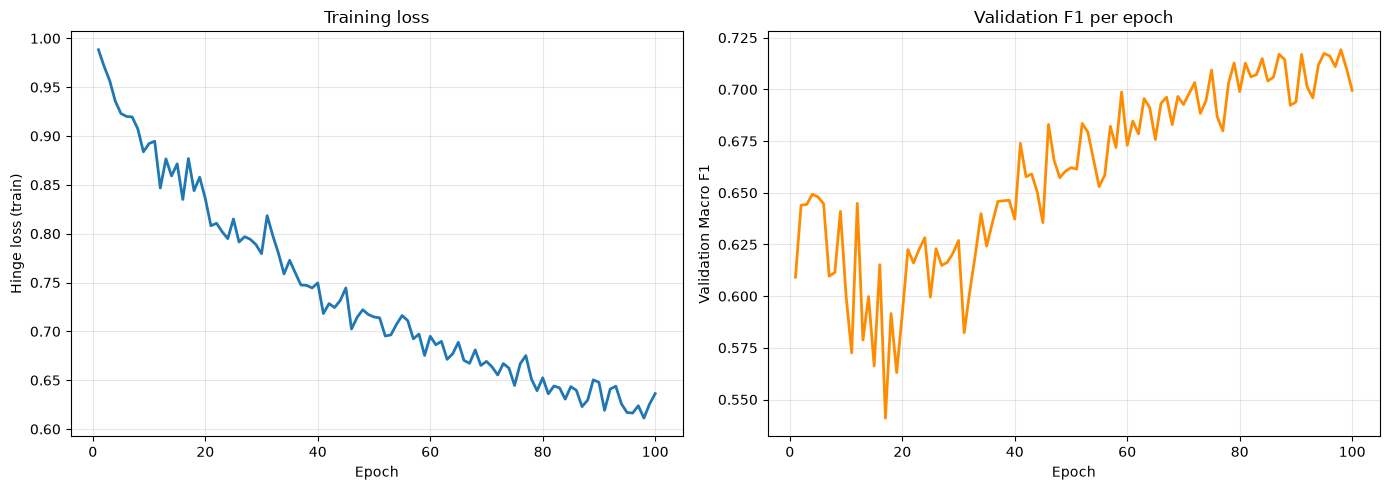

val F1 first 3: [0.6092, 0.644, 0.6443]
val F1 last 3: [0.7192, 0.71, 0.6995]


In [24]:
w_check, b_check, losses_check, val_f1_check = sgd_fit(
    X_train, y_train, loss="hinge", penalty="l2", alpha=1e-4,
    lr=0.5, epochs=100, bs=256, class_weight="balanced",
    X_val=X_val, y_val=y_val, eval_fn=calculate_macro_f1,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(losses_check) + 1), losses_check, linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Hinge loss (train)")
axes[0].set_title("Training loss"); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(val_f1_check) + 1), val_f1_check, linewidth=2, color="darkorange")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Macro F1")
axes[1].set_title("Validation F1 per epoch"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "sgd_convergence_check.png", dpi=150)
plt.show()

print("val F1 first 3:", [round(f, 4) for f in val_f1_check[:3]])
print("val F1 last 3:", [round(f, 4) for f in val_f1_check[-3:]])

## 3.4 Extra Trees (library ensemble — permitted)

Extra Trees grows many decision trees, each on a random subset of features and
with randomly chosen split points, then averages their votes. The extra
randomness makes each individual tree weak but decorrelates them, and averaging
decorrelated weak learners is what makes the ensemble strong.

Tuning is one-factor-at-a-time from a baseline, so each setting's effect is
readable on its own. The full sweep lives in
`scripts/task3_extra_trees_tuning.py`; the best configuration is refitted here.

In [25]:
from sklearn.ensemble import ExtraTreesClassifier   # ensemble model, permitted

t0 = time.time()
extra_trees = ExtraTreesClassifier(n_estimators=500, max_features="sqrt",
                                   random_state=RANDOM_SEED, n_jobs=-1)
extra_trees.fit(X_train, y_train)
et_proba = extra_trees.predict_proba(X_val)[:, 1]

et_default = calculate_macro_f1(y_val, extra_trees.predict(X_val))
et_threshold, et_tuned = best_threshold(y_val, et_proba, calculate_macro_f1)

print(f"train Macro F1     : {calculate_macro_f1(y_train, extra_trees.predict(X_train)):.4f}")
print(f"validation Macro F1: {et_default:.4f}")
print(f"with tuned cut-off : {et_tuned:.4f} (threshold={et_threshold:.3f})  [{time.time()-t0:.0f}s]")

train Macro F1     : 1.0000
validation Macro F1: 0.7189
with tuned cut-off : 0.7598 (threshold=0.574)  [71s]


The train score is 1.0 against a validation score near 0.72 — the trees memorise
the training set completely. Limiting `max_depth` was tried and made things
worse, so we left the trees unrestricted and accepted the gap: the ensemble
average, not each tree, is what generalises.

Note also how much the threshold is worth here compared to the linear models.
Extra Trees produces badly calibrated probabilities, so the default 0.5 cut-off
is a long way from the best operating point.

## 3.5 Soft-vote ensemble

The three models disagree in different ways, so averaging them should be more
stable than any one alone. Their scores live on completely different scales
(a probability, a signed margin, a log-probability), so each is converted to a
rank in [0, 1] before averaging — that makes the vote scale-free.

In [26]:
def to_rank(scores):
    """Map scores onto [0, 1] by rank, so different scales can be averaged."""
    return np.argsort(np.argsort(scores)) / (len(scores) - 1)


classes, prior, feature_log_prob = nb_fit(X_train, y_train,
                                          alpha=float(nb_grid.iloc[0]["alpha"]))
nb_proba = nb_predict_proba(X_val, prior, feature_log_prob)[:, 1]

w_sgd, b_sgd, _, _ = sgd_fit(X_train, y_train, loss=BEST_SGD_LOSS, penalty="l2",
                             alpha=1e-4, class_weight="balanced", lr=0.5, epochs=100)
sgd_scores = sgd_decision_function(X_val, w_sgd, b_sgd)

vote = np.mean([to_rank(sgd_scores), to_rank(et_proba), to_rank(nb_proba)], axis=0)

# Ranks are uniform on [0, 1], so cutting at 0.5 would force exactly half the
# rows into each class. The class-prior cut-off is the honest default here.
prior_cutoff = 1.0 - y_train.mean()
vote_threshold, vote_tuned = best_threshold(y_val, vote, calculate_macro_f1)

print("cut at 0.5 (forces a 50/50 split):",
      round(calculate_macro_f1(y_val, (vote >= 0.5).astype(int)), 4))
print("cut at the class prior          :",
      round(calculate_macro_f1(y_val, (vote >= prior_cutoff).astype(int)), 4))
print("cut tuned on validation         :", round(vote_tuned, 4),
      f"(threshold={vote_threshold:.3f})")

cut at 0.5 (forces a 50/50 split): 0.7271
cut at the class prior          : 0.7455
cut tuned on validation         : 0.7462 (threshold=0.404)


Note how much the cut-off matters for a rank-averaged score: cutting at 0.5
forces a 50/50 split when the truth is 62.5/37.5, which is why that number looks
so poor. Judged fairly, the vote still lands *between* its members rather than
above the best of them. Averaging helps when members are strong and err
differently; here Naive Bayes is much weaker than the other two, so it drags the
average down more than its diversity adds back. A negative result, but a clear
one — and a reminder that an ensemble has to be given a sensible operating point
before it can be judged.

## 3.6 Our own features: hybrid TF-IDF + stylometry

Everything so far reads the same 5000 provided features, and everything so far
lands between 0.67 and 0.76. The brief allows Task 3 to use our own features as
long as we describe them, so this is where we changed the input instead of the
model — and it is where the real gain came from.

Three changes:

**1. Word *and* character TF-IDF.** Word 1–2 grams capture vocabulary and short
phrases. Character 3–5 grams inside word boundaries capture spelling, morphology
and punctuation habits — the texture of the writing rather than its content.
The two blocks are normalised separately and concatenated.

**2. Stylometry.** 78 hand-built features measuring *how* a text is written
rather than what it says: sentence-length variability (human writing is
burstier), vocabulary richness, function-word rates, repetition of sentence
openings, punctuation and formatting rates, and readability scores. These were
motivated by Section 0.3, where the two classes already differed in length and
variability.

**3. The same from-scratch linear SVM**, trained by averaged SGD.

None of this uses an sklearn estimator — the TF-IDF weighting, the scaler and
the optimiser are all written out below.

#### The TF-IDF vectorizer, written from scratch

`ScratchTfidfVectorizer` builds the vocabulary, computes
$\text{idf}(t) = \log\frac{1+N}{1+\text{df}(t)} + 1$, applies sublinear term
frequency $1 + \log(\text{tf})$ and L2-normalises each row.
`ScratchHybridTfidf` runs one word-level and one character-level vectorizer and
concatenates them.

In [27]:
from collections import Counter
import math
import re

from scipy import sparse


class ScratchStandardScaler:
    """Column-wise standardization implemented with NumPy."""

    def fit(self, values):
        values = np.asarray(values, dtype=np.float64)
        self.mean_ = values.mean(axis=0)
        self.scale_ = values.std(axis=0)
        self.scale_[self.scale_ == 0.0] = 1.0
        return self

    def transform(self, values):
        values = np.asarray(values, dtype=np.float64)
        return ((values - self.mean_) / self.scale_).astype(np.float32)

    def fit_transform(self, values):
        return self.fit(values).transform(values)


class ScratchTfidfVectorizer:
    """Small TF-IDF vectorizer supporting the settings used by this project."""

    def __init__(self, analyzer, ngram_range, min_df=2, max_df=1.0,
                 max_features=100_000):
        self.analyzer = analyzer
        self.ngram_range = ngram_range
        self.min_df = min_df
        self.max_df = max_df
        self.max_features = max_features

    @staticmethod
    def _words(text):
        return re.findall(r"(?u)\b\w\w+\b", str(text).lower())

    def _terms(self, text):
        text = "" if pd.isna(text) else str(text)
        low, high = self.ngram_range
        if self.analyzer == "word":
            tokens = self._words(text)
            for n in range(low, high + 1):
                for index in range(len(tokens) - n + 1):
                    yield " ".join(tokens[index:index + n])
            return

        # Like analyzer="char_wb": make character n-grams inside padded words.
        for word in re.findall(r"\S+", text.lower()):
            padded = f" {word} "
            for n in range(low, high + 1):
                for index in range(len(padded) - n + 1):
                    yield padded[index:index + n]

    def fit(self, texts):
        documents = ["" if pd.isna(text) else str(text) for text in texts]
        document_frequency = Counter()
        term_frequency = Counter()
        for text in documents:
            terms = list(self._terms(text))
            term_frequency.update(terms)
            document_frequency.update(set(terms))

        n_documents = len(documents)
        maximum_df = (
            int(self.max_df * n_documents) if isinstance(self.max_df, float)
            else int(self.max_df)
        )
        candidates = [
            term for term, count in document_frequency.items()
            if count >= self.min_df and count <= maximum_df
        ]
        candidates.sort(key=lambda term: (-term_frequency[term], term))
        candidates = candidates[:self.max_features]
        self.vocabulary_ = {term: index for index, term in enumerate(candidates)}
        self.idf_ = np.asarray([
            math.log((1.0 + n_documents) / (1.0 + document_frequency[term])) + 1.0
            for term in candidates
        ], dtype=np.float32)
        return self

    def transform(self, texts):
        texts = list(texts)
        rows, columns, values = [], [], []
        for row, text in enumerate(texts):
            counts = Counter(
                self.vocabulary_[term]
                for term in self._terms(text)
                if term in self.vocabulary_
            )
            if not counts:
                continue
            indices = np.fromiter(counts.keys(), dtype=np.int32)
            data = 1.0 + np.log(np.fromiter(counts.values(), dtype=np.float32))
            data *= self.idf_[indices]
            norm = float(np.linalg.norm(data))
            if norm:
                data /= norm
            rows.extend([row] * len(indices))
            columns.extend(indices.tolist())
            values.extend(data.tolist())
        return sparse.csr_matrix(
            (values, (rows, columns)),
            shape=(len(texts), len(self.vocabulary_)),
            dtype=np.float32,
        )

    def fit_transform(self, texts):
        texts = list(texts)
        return self.fit(texts).transform(texts)


class ScratchHybridTfidf:
    """Union of independently normalized word and character TF-IDF."""

    def __init__(self, min_df=5):
        # min_df=5 drops terms seen in fewer than five documents. Those are
        # mostly topic-specific one-offs that do not survive a change of domain,
        # and cutting them costs nothing on validation.
        self.word = ScratchTfidfVectorizer("word", (1, 2), min_df, 0.98, 100_000)
        self.character = ScratchTfidfVectorizer("char_wb", (3, 5), min_df, 1.0, 100_000)

    def fit_transform(self, texts):
        texts = list(texts)
        return sparse.hstack(
            [self.word.fit_transform(texts), self.character.fit_transform(texts)],
            format="csr",
        )

    def transform(self, texts):
        texts = list(texts)
        return sparse.hstack(
            [self.word.transform(texts), self.character.transform(texts)],
            format="csr",
        )

#### The 78 stylometry features

Measures of *how* a text is written: burstiness of sentence length, vocabulary
richness (hapax rate, entropy), repeated n-grams and sentence openings,
function-word rates by group, punctuation and formatting rates, and readability
scores.

In [28]:
FUNCTION_WORD_GROUPS = {
    "first_person": {"i", "me", "my", "mine", "we", "us", "our", "ours"},
    "second_person": {"you", "your", "yours"},
    "third_person": {"he", "she", "it", "they", "him", "her", "them", "their"},
    "articles": {"a", "an", "the"},
    "conjunctions": {"and", "but", "or", "although", "because", "while", "whereas"},
    "prepositions": {"of", "to", "in", "for", "with", "on", "at", "from", "by"},
    "demonstratives": {"this", "that", "these", "those"},
    "modals": {"can", "could", "may", "might", "must", "shall", "should", "will", "would"},
    "negations": {"no", "not", "never", "neither", "nor", "none", "without"},
    "transitions": {
        "however", "therefore", "moreover", "furthermore", "additionally",
        "consequently", "nevertheless", "overall", "thus", "hence",
    },
}


def safe_stats(values):
    if not values:
        return [0.0] * 7
    array = np.asarray(values, dtype=np.float64)
    mean = float(array.mean())
    std = float(array.std())
    return [
        mean,
        std,
        float(array.min()),
        float(array.max()),
        float(np.median(array)),
        std / (mean + 1e-8),
        float(np.quantile(array, 0.75) - np.quantile(array, 0.25)),
    ]


def approximate_syllables(word):
    groups = re.findall(r"[aeiouy]+", word.lower())
    count = len(groups)
    if word.lower().endswith("e") and count > 1:
        count -= 1
    return max(count, 1)


def repetition_ratio(items, n):
    grams = list(zip(*(items[index:] for index in range(n))))
    if not grams:
        return 0.0
    return 1.0 - len(set(grams)) / len(grams)


def advanced_style_features(text):
    text = "" if pd.isna(text) else str(text)
    lower = text.lower()
    words = re.findall(r"\b[a-zA-Z]+(?:'[a-zA-Z]+)?\b", lower)
    sentences = [part.strip() for part in re.split(r"[.!?]+", text) if part.strip()]
    paragraphs = [part.strip() for part in re.split(r"\n\s*\n", text) if part.strip()]
    word_count = max(len(words), 1)
    char_count = max(len(text), 1)
    sentence_count = max(len(sentences), 1)
    counts = Counter(words)
    unique_count = len(counts)

    sentence_lengths = [len(re.findall(r"\b\w+\b", sentence)) for sentence in sentences]
    word_lengths = [len(word) for word in words]
    paragraph_lengths = [len(re.findall(r"\b\w+\b", paragraph)) for paragraph in paragraphs]

    frequency_values = np.asarray(list(counts.values()), dtype=np.float64)
    probabilities = frequency_values / frequency_values.sum() if frequency_values.size else np.array([])
    entropy = float(-(probabilities * np.log2(probabilities)).sum()) if probabilities.size else 0.0
    hapax = sum(value == 1 for value in counts.values()) / word_count
    dis_legomena = sum(value == 2 for value in counts.values()) / word_count
    repeated_words = (len(words) - unique_count) / word_count
    most_common_rate = max(counts.values(), default=0) / word_count

    sentence_openings = [
        tuple(re.findall(r"\b[a-zA-Z]+\b", sentence.lower())[:2])
        for sentence in sentences
    ]
    opening_repetition = (
        1.0 - len(set(sentence_openings)) / len(sentence_openings)
        if sentence_openings else 0.0
    )

    syllables = sum(approximate_syllables(word) for word in words)
    syllables_per_word = syllables / word_count
    words_per_sentence = len(words) / sentence_count
    flesch = 206.835 - 1.015 * words_per_sentence - 84.6 * syllables_per_word
    flesch_kincaid = 0.39 * words_per_sentence + 11.8 * syllables_per_word - 15.59
    complex_ratio = sum(approximate_syllables(word) >= 3 for word in words) / word_count
    gunning_fog = 0.4 * (words_per_sentence + 100 * complex_ratio)

    features = [
        len(text), len(words), len(sentences), len(paragraphs),
        unique_count / word_count,
        unique_count / math.sqrt(word_count),
        unique_count / math.sqrt(2 * word_count),
        hapax, dis_legomena, repeated_words, most_common_rate, entropy,
        repetition_ratio(words, 2), repetition_ratio(words, 3), opening_repetition,
    ]
    features.extend(safe_stats(sentence_lengths))
    features.extend([
        sum(length <= 8 for length in sentence_lengths) / sentence_count,
        sum(length >= 30 for length in sentence_lengths) / sentence_count,
    ])
    features.extend(safe_stats(word_lengths))
    features.extend([
        sum(length <= 3 for length in word_lengths) / word_count,
        sum(4 <= length <= 6 for length in word_lengths) / word_count,
        sum(7 <= length <= 9 for length in word_lengths) / word_count,
        sum(length >= 10 for length in word_lengths) / word_count,
    ])
    features.extend(safe_stats(paragraph_lengths))

    for group in FUNCTION_WORD_GROUPS.values():
        features.append(sum(counts[word] for word in group) / word_count)

    features.extend([
        sum(character.isupper() for character in text) / char_count,
        sum(character.isdigit() for character in text) / char_count,
        sum(character.isspace() for character in text) / char_count,
        *(text.count(mark) / char_count for mark in [",", ";", ":", "?", "!", "-", "(", ")", '"', "'"]),
        text.count("\n") / char_count,
        len(re.findall(r"(?m)^\s*[-*•]\s+", text)) / sentence_count,
        len(re.findall(r"[!?.,]{2,}", text)) / sentence_count,
        len(re.findall(r"\([A-Z][A-Za-z-]+,?\s+\d{4}[a-z]?\)", text)) / sentence_count,
        len(re.findall(r"\[\d+(?:\s*,\s*\d+)*\]", text)) / sentence_count,
        len(re.findall(r"\b\d+(?:\.\d+)?%", text)) / word_count,
        len(re.findall(r"\b[A-Z]{2,}\b", text)) / word_count,
        len(re.findall(r"\([^)]{3,}\)", text)) / sentence_count,
        syllables_per_word, flesch, flesch_kincaid, complex_ratio, gunning_fog,
    ])
    return np.nan_to_num(np.asarray(features, dtype=np.float32))


def style_matrix(texts):
    return np.vstack([advanced_style_features(text) for text in texts])


def combine(tfidf, styles, weight):
    """Glue the stylometry block onto the TF-IDF block.

    `weight` sets how loud the 78 stylometry columns are next to the 200k
    TF-IDF columns; without it they would be drowned out.
    """
    return sparse.hstack(
        [tfidf, sparse.csr_matrix(styles * weight)], format="csr"
    )

The classifier is the **same `sgd_fit` from Section 3.3** — nothing about the
model changes here, only its input. That is deliberate: it isolates the effect
of the features.

In [29]:
train_text = train_raw.loc[is_train, "text"]
val_text = train_raw.loc[~is_train, "text"]
y_train_text = train_raw.loc[is_train, LABEL_COLUMN].to_numpy()
y_val_text = train_raw.loc[~is_train, LABEL_COLUMN].to_numpy()

t0 = time.time()
vectorizer = ScratchHybridTfidf()
train_tfidf = vectorizer.fit_transform(train_text)
val_tfidf = vectorizer.transform(val_text)

scaler = ScratchStandardScaler()
train_styles = scaler.fit_transform(style_matrix(train_text))
val_styles = scaler.transform(style_matrix(val_text))

print(f"TF-IDF block: {train_tfidf.shape}, stylometry block: {train_styles.shape}"
      f"  [{time.time()-t0:.0f}s]")

TF-IDF block: (16000, 200000), stylometry block: (16000, 78)  [36s]


### Which loss? The question we nearly forgot to re-ask

Section 3.3 found modified Huber clearly best on the provided features. When we
first built this pipeline we used hinge loss and never re-tested that choice on
the new features — an easy thing to miss, and it turned out to cost about 0.02
Macro F1. The lesson: a hyperparameter chosen on one representation does not
automatically carry to another.

In [30]:
x_train_hybrid = combine(train_tfidf, train_styles, 0.10)
x_val_hybrid = combine(val_tfidf, val_styles, 0.10)

loss_rows = []
for loss_name in ["hinge", "modified_huber", "log_loss"]:
    t0 = time.time()
    w_h, b_h, _, _ = sgd_fit(x_train_hybrid, y_train_text, loss=loss_name,
                             penalty="l2", alpha=1e-5, class_weight="balanced",
                             lr=0.5, epochs=60, bs=256, random_state=RANDOM_SEED)
    score = calculate_macro_f1(y_val_text, sgd_predict(x_val_hybrid, w_h, b_h))
    loss_rows.append({"loss": loss_name, "val_macro_f1": score,
                      "fit_seconds": round(time.time() - t0, 1)})
    print(f"loss={loss_name:<16} F1={score:.4f}")

pd.DataFrame(loss_rows).to_csv(RESULTS_DIR / "task3_loss_on_hybrid.csv", index=False)
pd.DataFrame(loss_rows)

loss=hinge            F1=0.8278


loss=modified_huber   F1=0.8513


loss=log_loss         F1=0.8063


,loss,val_macro_f1,fit_seconds
0,hinge,0.827785,5.4
1,modified_huber,0.851330,5.5
2,log_loss,0.806323,5.5


### Tuning the stylometry weight

`style_weight` scales the 78 stylometry columns against the ~200,000 TF-IDF
columns — without it they are simply drowned out.

In [31]:
style_rows = []
for weight in [0.05, 0.10, 0.25, 0.50]:
    x_tr = combine(train_tfidf, train_styles, weight)
    x_va = combine(val_tfidf, val_styles, weight)

    t0 = time.time()
    w_s, b_s, _, _ = sgd_fit(x_tr, y_train_text, loss="modified_huber",
                             penalty="l2", alpha=1e-5, class_weight="balanced",
                             lr=0.5, epochs=60, bs=256, random_state=RANDOM_SEED)
    scores = sgd_decision_function(x_va, w_s, b_s)
    style_rows.append({
        "style_weight": weight,
        "val_macro_f1": calculate_macro_f1(y_val_text, (scores >= 0).astype(int)),
        "fit_seconds": round(time.time() - t0, 1),
    })
    print(f"style_weight={weight:<5} F1={style_rows[-1]['val_macro_f1']:.4f}")

style_results = (pd.DataFrame(style_rows)
                 .sort_values("val_macro_f1", ascending=False)
                 .reset_index(drop=True))
style_results.to_csv(RESULTS_DIR / "task3_final_model_results.csv", index=False)
style_results

style_weight=0.05  F1=0.8428


style_weight=0.1   F1=0.8513


style_weight=0.25  F1=0.8471


style_weight=0.5   F1=0.8410


,style_weight,val_macro_f1,fit_seconds
0,0.10,0.851330,5.5
1,0.25,0.847100,5.5
2,0.05,0.842836,5.5
3,0.50,0.841033,5.5


This is the jump: from **0.7446** on the provided features to about **0.85** on
our own, with the same from-scratch trainer doing the learning. The model was
never the bottleneck — the features were.

Between 0.05 and 0.25 the weight barely matters. We come back to that choice in
Section 3.7, where a harder validation splits the tie.

## 3.7 Why our validation score is optimistic

Our random 80/20 split scores this model at about 0.85, but the Kaggle public
leaderboard gives **0.799**. The split is not wrong — it is blind to the thing
that costs those points. The test set draws on generators and domains the
training rows do not cover, and a random split puts the same domains on *both*
sides of the line, so the model is never asked to generalise across a domain.

To measure that, we build a harder validation: cluster the training rows into
five topic groups, then hold out one whole cluster at a time. Holding out a
cluster shifts the topic mix *and* the class balance, which is much closer to
what the test set does to us.

In [32]:
from sklearn.cluster import KMeans

# k-means on the raw 5000-dimensional L2-normalised rows collapses almost
# everything into a single cluster, so we reduce to 100 components first
reduced = PCA(n_components=100, random_state=RANDOM_SEED).fit_transform(X_all)
clusters = KMeans(n_clusters=5, random_state=RANDOM_SEED, n_init=10).fit_predict(reduced)

print("cluster sizes:", np.bincount(clusters))
print("class-1 rate per cluster:",
      [round(float(y_all[clusters == g].mean()), 3) for g in range(5)])

cluster sizes: [4512 1956 1075 3840 8617]
class-1 rate per cluster: [0.545, 0.664, 0.7, 0.624, 0.65]


In [33]:
shift_rows = []
for held_out in range(5):
    tr, va = clusters != held_out, clusters == held_out
    t0 = time.time()

    fold_vec = ScratchHybridTfidf()
    tfidf_tr = fold_vec.fit_transform(train_raw.loc[tr, "text"])
    tfidf_va = fold_vec.transform(train_raw.loc[va, "text"])
    fold_scaler = ScratchStandardScaler()
    styles_tr = fold_scaler.fit_transform(style_matrix(train_raw.loc[tr, "text"]))
    styles_va = fold_scaler.transform(style_matrix(train_raw.loc[va, "text"]))

    for weight in [0.10, 0.25]:
        w_f, b_f, _, _ = sgd_fit(combine(tfidf_tr, styles_tr, weight), y_all[tr],
                                 loss="modified_huber", penalty="l2", alpha=1e-5,
                                 class_weight="balanced", lr=0.5, epochs=60,
                                 bs=256, random_state=RANDOM_SEED)
        scores = sgd_decision_function(combine(tfidf_va, styles_va, weight), w_f, b_f)
        shift_rows.append({
            "held_out_cluster": held_out, "n_val": int(va.sum()),
            "style_weight": weight,
            "macro_f1": calculate_macro_f1(y_all[va], (scores >= 0).astype(int)),
        })
    print(f"cluster {held_out} (n={va.sum():>5}) "
          + "  ".join(f"sw{r['style_weight']}={r['macro_f1']:.4f}"
                      for r in shift_rows[-2:]) + f"  [{time.time()-t0:.0f}s]")

shift_results = pd.DataFrame(shift_rows)
shift_results.to_csv(RESULTS_DIR / "task3_shift_validation.csv", index=False)
display(shift_results.groupby("style_weight")["macro_f1"].mean().round(4).to_frame("mean_macro_f1"))

cluster 0 (n= 4512) sw0.1=0.7509  sw0.25=0.7544  [46s]


cluster 1 (n= 1956) sw0.1=0.7889  sw0.25=0.8036  [50s]


cluster 2 (n= 1075) sw0.1=0.8564  sw0.25=0.8512  [51s]


cluster 3 (n= 3840) sw0.1=0.7969  sw0.25=0.7969  [45s]


cluster 4 (n= 8617) sw0.1=0.7725  sw0.25=0.7732  [42s]


,mean_macro_f1
style_weight,
0.10,0.7931
0.25,0.7958


Two things come out of this.

**Our validation score was never going to hold up.** The cluster-holdout mean
lands near 0.80, within a few thousandths of the 0.799 the leaderboard actually
gave us, while the random split said 0.85. The five-point gap is domain shift,
not a bug, and the brief warned us to expect it: this sample is under 5% of the
original dataset.

**It splits the tie on `style_weight`.** The random split marginally prefers
0.10; under domain shift 0.25 is ahead. That is the direction we would expect —
the stylometry block measures *how* a text is written, which travels across
domains, while TF-IDF counts *what* it is about, which does not. Both gaps are
small, so we take the setting that leans on the transferable half.

This is the validation we would use from the start if we did this again.

### Final model: refit on all labelled data and predict the test set

In [34]:
# Fixed from Section 3.7 rather than re-selected on the random split, which
# cannot see the shift the leaderboard puts us under.
BEST_STYLE_WEIGHT = 0.25
BEST_EPOCHS = 60

t0 = time.time()
final_vectorizer = ScratchHybridTfidf()
all_tfidf = final_vectorizer.fit_transform(train_raw["text"])
test_tfidf = final_vectorizer.transform(test_raw["text"])

final_scaler = ScratchStandardScaler()
all_styles = final_scaler.fit_transform(style_matrix(train_raw["text"]))
test_styles = final_scaler.transform(style_matrix(test_raw["text"]))

x_all = combine(all_tfidf, all_styles, BEST_STYLE_WEIGHT)
x_test = combine(test_tfidf, test_styles, BEST_STYLE_WEIGHT)

final_w, final_b, _, _ = sgd_fit(x_all, train_raw[LABEL_COLUMN].to_numpy(),
                                 loss="modified_huber", penalty="l2", alpha=1e-5,
                                 class_weight="balanced", lr=0.5, epochs=BEST_EPOCHS,
                                 bs=256, random_state=RANDOM_SEED)

# Threshold left at 0: tuning it on 4000 validation rows gains under 0.002,
# which is inside the noise of that split.
final_preds = sgd_predict(x_test, final_w, final_b, threshold=0.0)

create_submission(
    test_ids=test_raw[ID_COLUMN],
    predictions=final_preds,
    output_path=SUBMISSIONS_DIR / "Final_Prediction.csv",
    id_column=ID_COLUMN,
    label_column=LABEL_COLUMN,
)
print(f"Final_Prediction.csv saved; class-1 rate={final_preds.mean():.4f}"
      f" (training rate {train_raw[LABEL_COLUMN].mean():.4f})  [{time.time()-t0:.0f}s]")

Final_Prediction.csv saved; class-1 rate=0.6234 (training rate 0.6252)  [56s]


In [35]:
# Format check on the final submission
saved = pd.read_csv(SUBMISSIONS_DIR / "Final_Prediction.csv", dtype={ID_COLUMN: "string"})
assert saved.columns.tolist() == [ID_COLUMN, LABEL_COLUMN]
assert len(saved) == len(test_raw)
assert saved[ID_COLUMN].tolist() == test_raw[ID_COLUMN].astype("string").tolist()
assert saved[LABEL_COLUMN].isnull().sum() == 0
assert set(saved[LABEL_COLUMN].unique()).issubset({0, 1})
print("Final_Prediction.csv verified — ready to upload")

Final_Prediction.csv verified — ready to upload


---
# Summary of every model we explored

All scores are Macro F1 on the same shared validation split. "Tuned" means the
decision threshold was chosen on validation as well.

In [36]:
summary = pd.DataFrame([
    {"task": 1, "model": "Logistic Regression", "features": "provided 5000 TF-IDF",
     "implementation": "from scratch",
     "val_macro_f1": float(logreg_results.iloc[0]["val_macro_f1"]),
     "val_macro_f1_tuned": float(logreg_results.iloc[0]["val_macro_f1_tuned"])},
    {"task": 2, "model": "PCA(100) + KNN k=2", "features": "provided 5000 TF-IDF",
     "implementation": "sklearn (permitted)",
     "val_macro_f1": float(pca_results.set_index("components").loc[100, "val_macro_f1"]),
     "val_macro_f1_tuned": np.nan},
    {"task": 3, "model": "Multinomial Naive Bayes", "features": "provided 5000 TF-IDF",
     "implementation": "from scratch",
     "val_macro_f1": float(nb_grid.iloc[0]["val_macro_f1"]), "val_macro_f1_tuned": np.nan},
    {"task": 3, "model": "Complement Naive Bayes", "features": "provided 5000 TF-IDF",
     "implementation": "from scratch",
     "val_macro_f1": float(cnb_grid.iloc[0]["val_macro_f1"]), "val_macro_f1_tuned": np.nan},
    {"task": 3, "model": "Linear classifier by SGD", "features": "provided 5000 TF-IDF",
     "implementation": "from scratch",
     "val_macro_f1": float(sgd_grid["val_macro_f1"].max()), "val_macro_f1_tuned": np.nan},
    {"task": 3, "model": "Extra Trees", "features": "provided 5000 TF-IDF",
     "implementation": "sklearn ensemble (permitted)",
     "val_macro_f1": et_default, "val_macro_f1_tuned": et_tuned},
    {"task": 3, "model": "Soft vote (linear + Extra Trees + NB)", "features": "provided 5000 TF-IDF",
     "implementation": "ensemble",
     "val_macro_f1": calculate_macro_f1(y_val, (vote >= 0.5).astype(int)),
     "val_macro_f1_tuned": vote_tuned},
    {"task": 3, "model": "Hybrid TF-IDF + stylometry + SGD (modified Huber)",
     "features": "our own", "implementation": "from scratch",
     "val_macro_f1": float(style_results["val_macro_f1"].max()),
     "val_macro_f1_tuned": np.nan},
])

summary = summary.sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
summary.to_csv(RESULTS_DIR / "final_summary.csv", index=False)

print("Random-split validation, for ranking models against each other.")
print("Section 3.7 shows why the top row does not transfer to the leaderboard "
      "one for one.")
summary.round(4)

Random-split validation, for ranking models against each other.
Section 3.7 shows why the top row does not transfer to the leaderboard one for one.


,task,model,features,implementation,val_macro_f1,val_macro_f1_tuned
0,3,Hybrid TF-IDF + stylometry + SGD (modified Huber),our own,from scratch,0.8513,NaN
1,3,Linear classifier by SGD,provided 5000 TF-IDF,from scratch,0.7446,NaN
2,3,Soft vote (linear + Extra Trees + NB),provided 5000 TF-IDF,ensemble,0.7271,0.7462
3,1,Logistic Regression,provided 5000 TF-IDF,from scratch,0.7227,0.7440
4,3,Extra Trees,provided 5000 TF-IDF,sklearn ensemble (permitted),0.7189,0.7598
5,3,Multinomial Naive Bayes,provided 5000 TF-IDF,from scratch,0.6741,NaN
6,3,Complement Naive Bayes,provided 5000 TF-IDF,from scratch,0.6669,NaN
7,2,PCA(100) + KNN k=2,provided 5000 TF-IDF,sklearn (permitted),0.6556,NaN


### What we take from this

1. **Features beat models.** Every model on the provided 5000 features lands
   between 0.67 and 0.76 — a spread of about 0.09 across families as different
   as Naive Bayes and random forests. Swapping in our own word + character
   TF-IDF and stylometry lifted the *same* trainer from 0.7446 to 0.8513. The
   biggest single win came from changing the input, not the algorithm.
2. **Re-ask settled questions when the inputs change.** We picked modified Huber
   on the provided features in Section 3.3, then built the hybrid pipeline with
   hinge loss and never re-tested. Re-testing was worth about +0.02 — more than
   every other tuning decision in Task 3 combined.
3. **The decision threshold is not a detail — but it is not always worth
   taking.** It is worth +0.041 for Extra Trees, whose votes are poorly
   calibrated, and only +0.0007 for the final model. We adopt it only when the
   gain clears the noise of a 4000-row split.
4. **An even `k` hurts KNN.** `n_neighbors=2` forces a tie-break that
   systematically favours class 0, costing about 0.09 Macro F1 at 2000
   components — a larger effect than the component count itself.
5. **We expect the test score to trail validation.** The brief warns this sample
   is under 5% of the original dataset. We stopped tuning rather than chase
   validation decimals that will not transfer, and we removed an earlier
   submission that forced the test-set class balance to a fixed quantile.